## Model Training

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [2]:
## basic imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#modelling
from sklearn.metrics import mean_squared_error , r2_score , mean_absolute_error , mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor , AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import train_test_split , RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings


#### Import the CSV Data as Pandas DataFrame

In [3]:
df = pd.read_csv(r'data/stud.csv')
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [4]:
X = df.drop(columns='math_score', axis=1)
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [5]:
y = df['math_score']
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [6]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
      [
            ("OneHotEncoder", oh_transformer , cat_features ),
            ("StandardScaler", numeric_transformer , num_features  )
      ]
)

In [7]:
X = preprocessor.fit_transform(X)

In [8]:
X.shape

(1000, 19)

In [9]:
X[:5]

array([[ 1.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  1.        ,  0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  1.        ,
         1.        ,  0.        ,  1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  1.        ,  1.77010859,  1.64247471],
       [ 0.        ,  1.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.   

In [10]:
X_train , X_test , y_train , y_test = train_test_split(X ,y, train_size=0.8 , random_state=401  )
X_train.shape , X_test.shape , y_train.shape

((800, 19), (200, 19), (800,))

In [11]:
def evalution_metrics(true , predicted):
      mae = mean_absolute_error(true,predicted)
      mse = mean_squared_error(true , predicted)
      rmse = np.sqrt(mse)
      r2_square = r2_score(true , predicted)
      return mae , mse , rmse , r2_square

In [12]:
models = {
      "linear regression": LinearRegression(),
      "Lasso" : Lasso(),
      "Ridge" : Ridge(),
      "K-Neighbours Regressor" : KNeighborsRegressor(),
      "Decision Tree" : DecisionTreeRegressor(),
      "Random Forest Regressor" : RandomForestRegressor(),
      "XGBoost" : XGBRegressor(),
      "CatBoost Regressor": CatBoostRegressor(verbose=False),
      "AdaBoost Regressor": AdaBoostRegressor()
}

model_list= []
r2_lists = []
r2_list = []

for i in range(len(list(models))):
      model = list(models.values())[i]
      model.fit(X_train,y_train)
      
      y_train_pred = model.predict(X_train)
      y_test_pred = model.predict(X_test)
      
      # Evaluate Train and Test dataset

      model_train_mae , model_train_mse , model_train_rmse , model_train_r2_score = evalution_metrics(y_train , y_train_pred )
      model_test_mae , model_test_mse , model_test_rmse , model_test_r2_score = evalution_metrics(y_test , y_test_pred )
      
      print(list(models.keys())[i])
      model_list.append(list(models.keys())[i])
      r2_list.append(model_test_r2_score)
      r2_lists.append({"train r2 score" : model_train_r2_score , "test r2 score" : model_test_r2_score  })
      
      print("models performance for train set")
      print(" mean absolute error: {:.4f}".format(model_train_mae))
      print(" mean squared error: {:.4f}".format(model_train_mse))
      print(" root mean squared error: {:.4f}".format(model_train_rmse))
      print(" model r2 square : {:.4f}".format(model_train_r2_score))
      print("-"*20)
      print("models performance for test set")
      print(" mean absolute error: {:.4f}".format(model_test_mae))
      print(" mean squared error: {:.4f}".format(model_test_mse))
      print(" root mean squared error: {:.4f}".format(model_test_rmse))
      print(" model r2 square : {:.4f}".format(model_test_r2_score))
      print("="*20)
      print("\n")

linear regression
models performance for train set
 mean absolute error: 4.1784
 mean squared error: 27.7224
 root mean squared error: 5.2652
 model r2 square : 0.8814
--------------------
models performance for test set
 mean absolute error: 4.5470
 mean squared error: 31.1491
 root mean squared error: 5.5811
 model r2 square : 0.8540


Lasso
models performance for train set
 mean absolute error: 5.1622
 mean squared error: 42.6264
 root mean squared error: 6.5289
 model r2 square : 0.8176
--------------------
models performance for test set
 mean absolute error: 5.1695
 mean squared error: 43.2983
 root mean squared error: 6.5801
 model r2 square : 0.7971


Ridge
models performance for train set
 mean absolute error: 4.1773
 mean squared error: 27.7252
 root mean squared error: 5.2655
 model r2 square : 0.8814
--------------------
models performance for test set
 mean absolute error: 4.5411
 mean squared error: 31.1112
 root mean squared error: 5.5777
 model r2 square : 0.8542


K-Ne

In [13]:
r2_list , model_list

([0.8540067316920821,
  0.797064577997508,
  0.8541844314221136,
  0.7879396325459318,
  0.666010498687664,
  0.8134608616787485,
  0.7802963256835938,
  0.8308952530099102,
  0.8088330034310679],
 ['linear regression',
  'Lasso',
  'Ridge',
  'K-Neighbours Regressor',
  'Decision Tree',
  'Random Forest Regressor',
  'XGBoost',
  'CatBoost Regressor',
  'AdaBoost Regressor'])

### Results

In [14]:
pd.DataFrame(list(zip(model_list , r2_list )), columns=['Model Name' , 'r2 score']).sort_values(by='r2 score',ascending=False)

,Model Name,r2 score
2,Ridge,0.854184
0,linear regression,0.854007
7,CatBoost Regressor,0.830895
5,Random Forest Regressor,0.813461
8,AdaBoost Regressor,0.808833
1,Lasso,0.797065
3,K-Neighbours Regressor,0.787940
6,XGBoost,0.780296
4,Decision Tree,0.666010


In [15]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train,y_train)
y_pred_linear = lin_model.predict(X_test)
score = r2_score( y_test , y_pred_linear )
print( "accuracy of the model is - {:.4f}".format(score*100) )

accuracy of the model is - 85.4007


In [16]:
ridge_model = Ridge()
ridge_model = ridge_model.fit(X_train , y_train)
y_pred_ridge = ridge_model.predict(X_test)
score = r2_score(y_test , y_pred_ridge)
print( "accuracy of the model is - {:.4f}".format(score*100) )

accuracy of the model is - 85.4184


## Plot y_pred and y_test

Text(0, 0.5, 'Prediction')

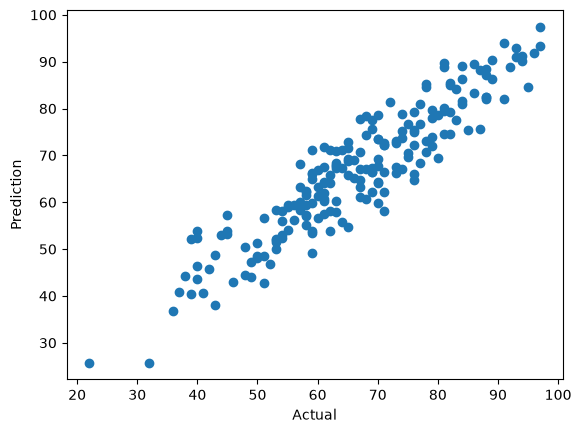

In [17]:
plt.scatter(y_test , y_pred_linear)
plt.xlabel('Actual')
plt.ylabel('Prediction')

<Axes: xlabel='math_score'>

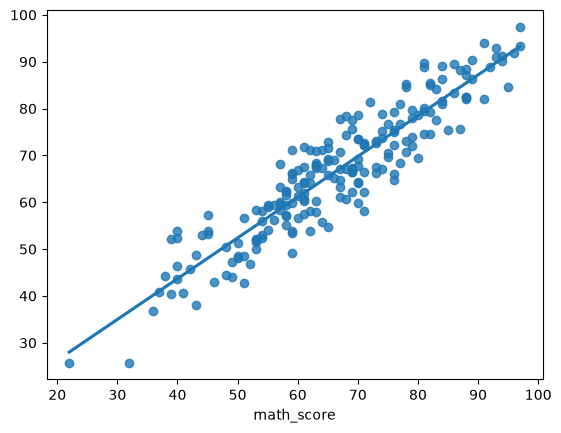

In [18]:
sns.regplot(x=y_test , y=y_pred_linear , ci=None )

<Axes: xlabel='math_score'>

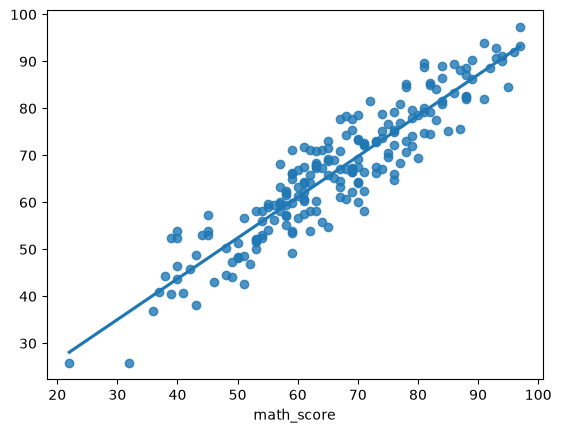

In [19]:
sns.regplot(x=y_test , y=y_pred_ridge , ci=None )

#### Difference between Actual and Predicted Values

In [22]:
diff_df = pd.DataFrame({'Actual value ' : y_test , "Predicted value ":y_pred_linear , "Difference ":y_test-y_pred_linear })
diff_df

,Actual value,Predicted value,Difference
32,56,59.324454,-3.324454
871,70,64.351149,5.648851
423,59,71.163866,-12.163866
142,42,45.813043,-3.813043
69,39,52.218143,-13.218143
...,...,...,...
530,68,60.618821,7.381179
527,36,36.772961,-0.772961
280,53,52.078131,0.921869
684,62,71.214214,-9.214214
